# STEP 04 — Baseline Policies

Egy RL agentet **soha nem értékelünk önmagában**. Ha egy random vagy egyszerű szabályalapú controller ugyanazt tudja, akkor a drágább és bonyolultabb RL rendszernek nincs bizonyított hozzáadott értéke.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. A négy baseline

- **No Battery:** az akkumulátort egyáltalán nem használjuk.
- **Random Valid:** véletlenszerű, de fizikailag érvényes action.
- **Rule-Based:** olcsó árnál charge, drága árnál discharge.
- **Perfect-Information Heuristic:** az egész napi árprofilt látó, oracle-szerű referencia. Ez nem fair online versenytárs, inkább felső referencia.

In [2]:
from battery_rl.agents.baselines import NoBatteryAgent, RandomValidAgent, RuleBasedAgent, PerfectInformationHeuristicAgent
from battery_rl.evaluation import evaluate_policy

low = float(train.electricity_price_eur_per_kwh.quantile(0.30))
high = float(train.electricity_price_eur_per_kwh.quantile(0.75))
print(f"Rule-based thresholds: low={low:.4f} EUR/kWh, high={high:.4f} EUR/kWh")

Rule-based thresholds: low=0.0980 EUR/kWh, high=0.1561 EUR/kWh


## 2. Rule-based küszöbök vizuálisan

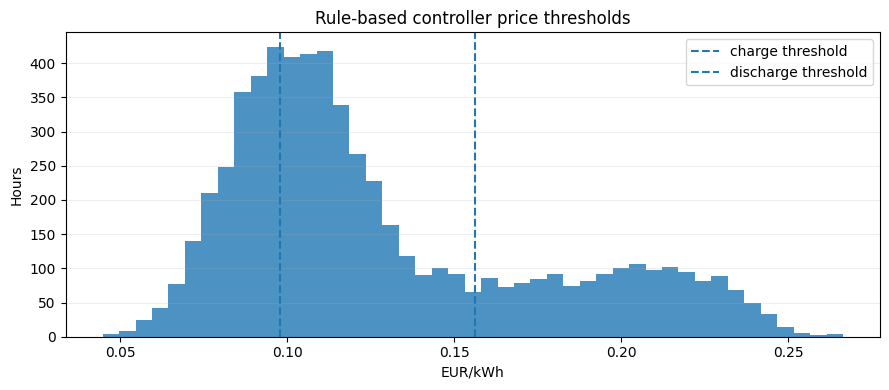

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train.electricity_price_eur_per_kwh, bins=45, alpha=0.8)
ax.axvline(low, linestyle="--", label="charge threshold")
ax.axvline(high, linestyle="--", label="discharge threshold")
ax.set_title("Rule-based controller price thresholds")
ax.set_xlabel("EUR/kWh"); ax.set_ylabel("Hours"); ax.legend(); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_01_rule_thresholds.png", dpi=170, bbox_inches="tight")
plt.show()

## 3. Baseline-ok értékelése ugyanazon test distributionön

In [4]:
agents = [
    NoBatteryAgent(),
    RandomValidAgent(seed=42),
    RuleBasedAgent(low, high),
    PerfectInformationHeuristicAgent(),
]
rows, all_logs = [], []
episodes = 8 if QUICK_MODE else 40
for agent in agents:
    metrics, logs = evaluate_policy(lambda: build_env(test, cfg, random_start=True), agent, seeds=SEEDS, episodes=episodes)
    row = metrics.mean(numeric_only=True).to_dict()
    row.update({f"{k}_std": v for k, v in metrics.std(numeric_only=True).to_dict().items()})
    row["policy"] = agent.name
    rows.append(row)
    logs["policy"] = agent.name
    all_logs.append(logs)

comparison = pd.DataFrame(rows)
nb_cost = comparison.loc[comparison.policy == "No Battery", "total_electricity_cost"].iloc[0]
nb_peak = comparison.loc[comparison.policy == "No Battery", "peak_grid_demand_kw"].iloc[0]
comparison["cost_saving_pct"] = 100 * (nb_cost - comparison.total_electricity_cost) / nb_cost
comparison["peak_reduction_pct"] = 100 * (nb_peak - comparison.peak_grid_demand_kw) / nb_peak
display(comparison[["policy","total_electricity_cost","cost_saving_pct","peak_grid_demand_kw","peak_reduction_pct","battery_cycles","constraint_violations"]])

,policy,total_electricity_cost,cost_saving_pct,peak_grid_demand_kw,peak_reduction_pct,battery_cycles,constraint_violations
0,No Battery,104.612954,0.000000,67.194335,0.000000,0.000000,0.00
1,Random,111.408874,-6.496251,93.472576,-39.107823,1.806538,3.25
2,Rule-based,97.437420,6.859125,73.123718,-8.824232,0.805510,2.25
3,Perfect-info heuristic,96.164092,8.076305,72.177956,-7.416728,0.736801,2.00


## 4. Electricity cost comparison

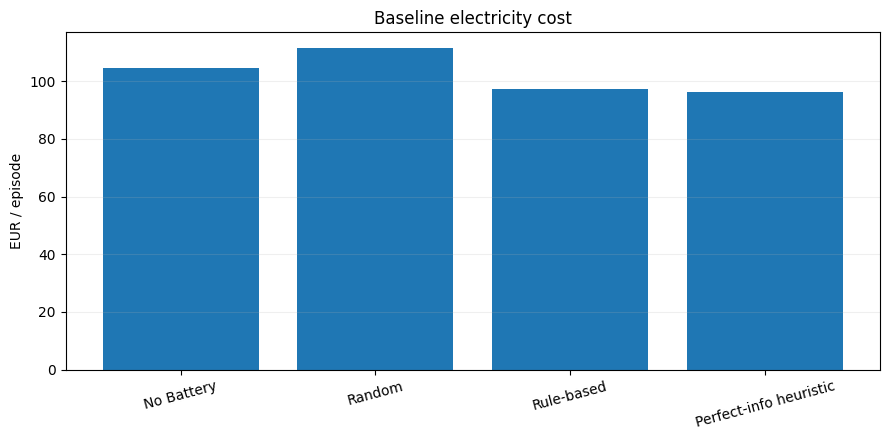

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.total_electricity_cost)
ax.set_title("Baseline electricity cost")
ax.set_ylabel("EUR / episode"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_02_baseline_cost.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. Peak grid demand comparison

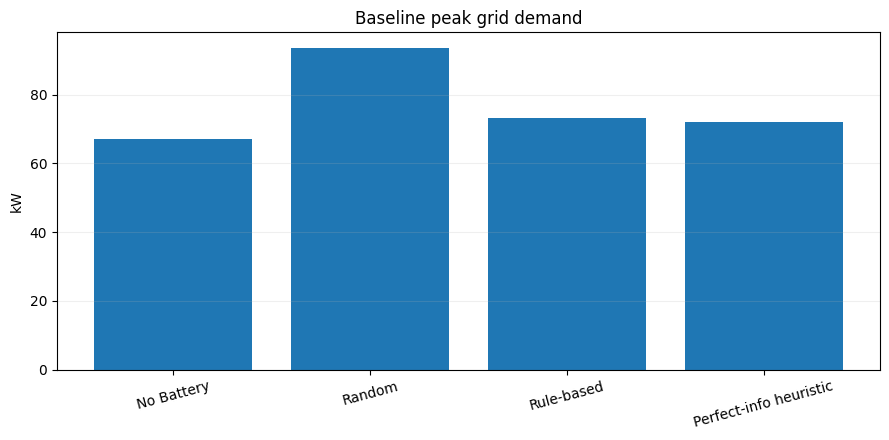

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.peak_grid_demand_kw)
ax.set_title("Baseline peak grid demand")
ax.set_ylabel("kW"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_03_baseline_peak.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Battery cycles — az olcsóbb nem mindig jobb

Két policy azonos költséget érhet el teljesen eltérő battery throughputtal. A több ciklus várhatóan gyorsabb öregedést jelent, ezért a cost mellett külön KPI-ként tartjuk meg.

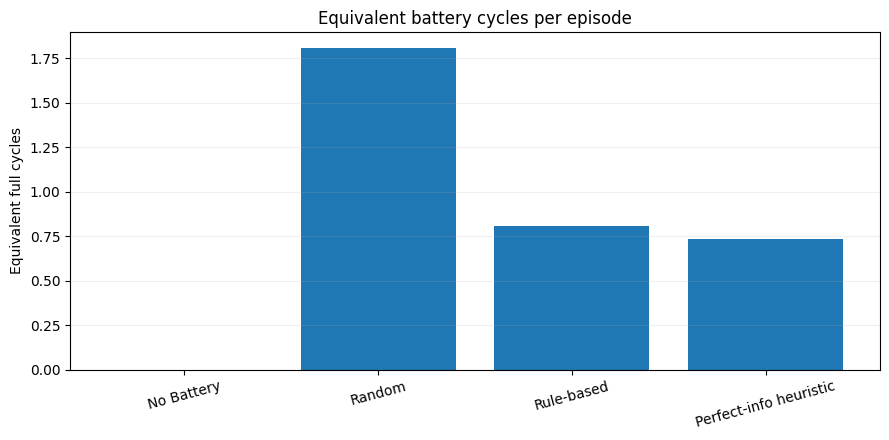

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.battery_cycles)
ax.set_title("Equivalent battery cycles per episode")
ax.set_ylabel("Equivalent full cycles"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_04_baseline_cycles.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Renewable self-consumption

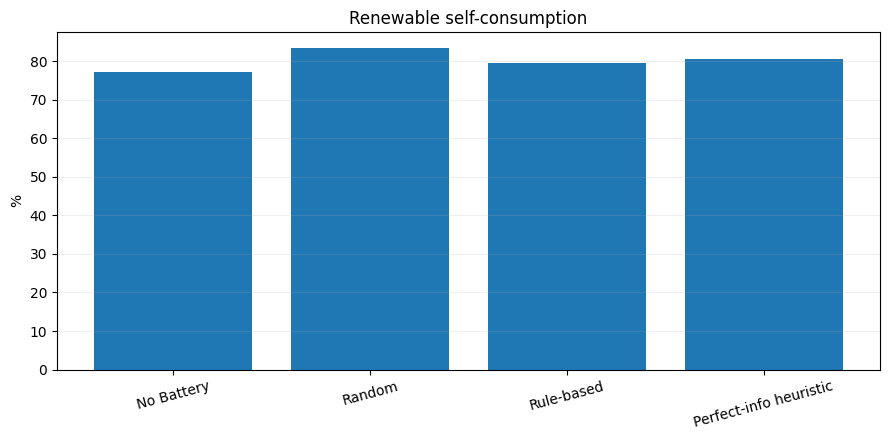

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison.policy, comparison.renewable_self_consumption_pct)
ax.set_title("Renewable self-consumption")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_05_baseline_self_consumption.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Reprezentatív SOC trajektóriák

Az aggregált KPI-k mellett fontos látni **hogyan** jut el a controller az eredményhez. Az alábbi ábra az első értékelt episode SOC-ját hasonlítja össze.

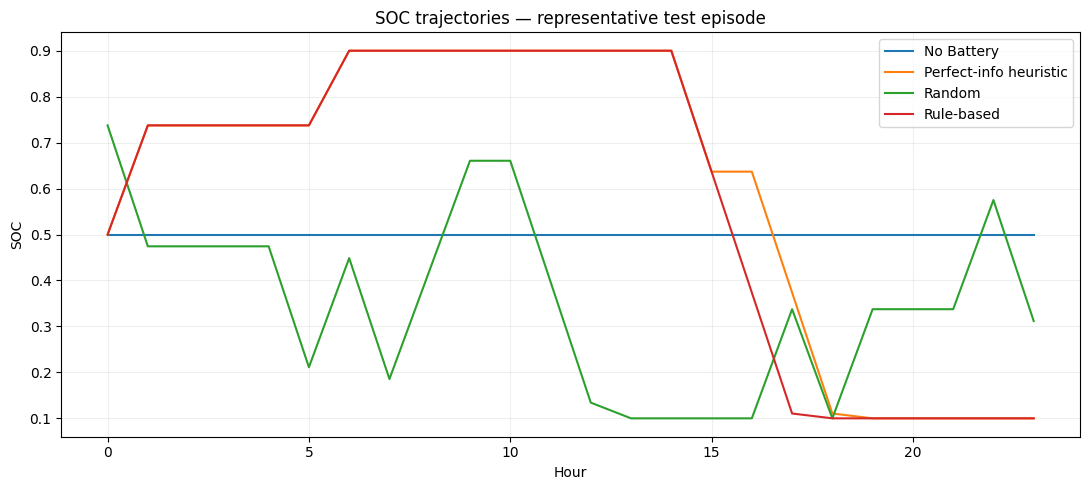

In [9]:
logs_all = pd.concat(all_logs, ignore_index=True)
fig, ax = plt.subplots(figsize=(11, 5))
for policy, part in logs_all[logs_all.episode == 0].groupby("policy"):
    ax.plot(np.arange(len(part)), part.soc.to_numpy(), label=policy)
ax.set_title("SOC trajectories — representative test episode")
ax.set_xlabel("Hour"); ax.set_ylabel("SOC"); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_06_soc_trajectories.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Battery power trajektóriák

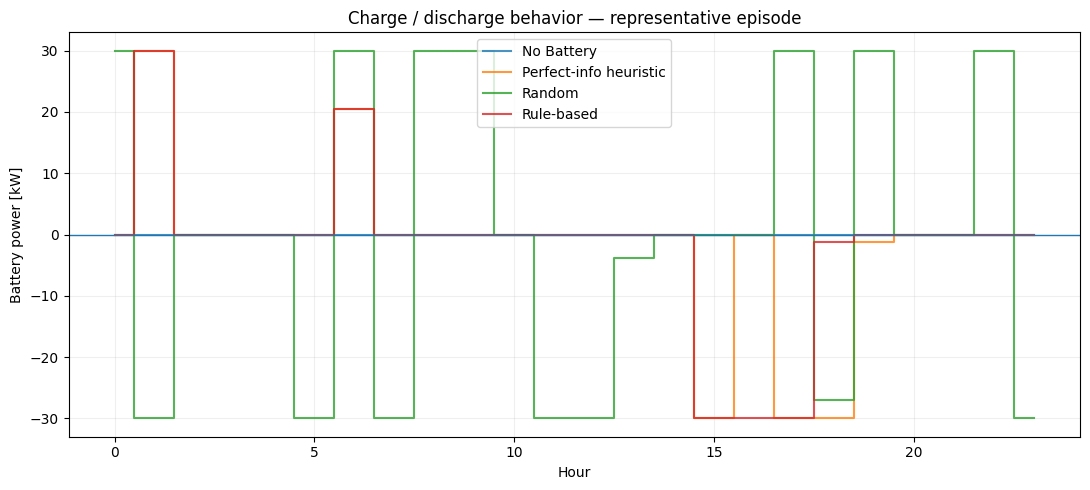

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for policy, part in logs_all[logs_all.episode == 0].groupby("policy"):
    ax.step(np.arange(len(part)), part.executed_battery_power_kw.to_numpy(), where="mid", label=policy, alpha=0.8)
ax.axhline(0, linewidth=1)
ax.set_title("Charge / discharge behavior — representative episode")
ax.set_xlabel("Hour"); ax.set_ylabel("Battery power [kW]"); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_07_battery_power_trajectories.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Cumulative electricity cost az episode során

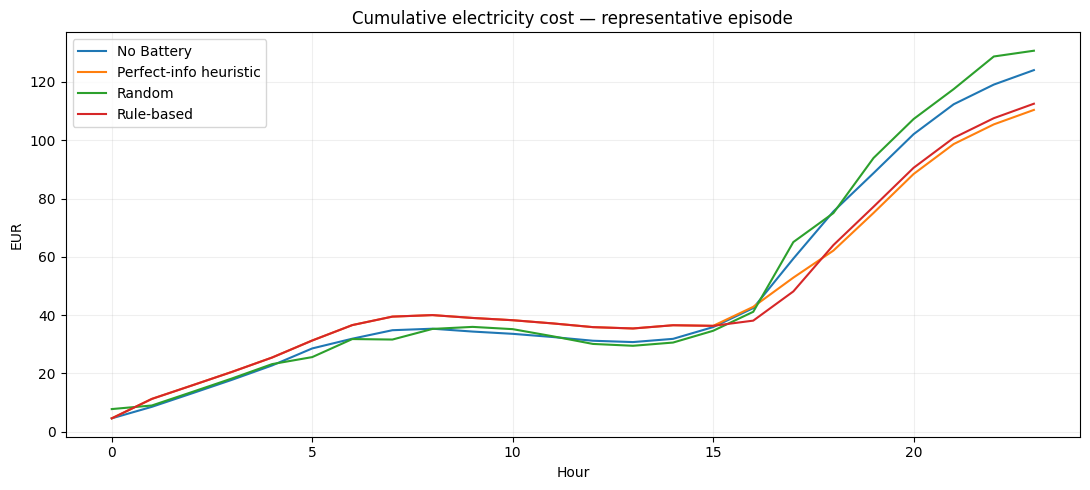

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for policy, part in logs_all[logs_all.episode == 0].groupby("policy"):
    ax.plot(np.arange(len(part)), part.electricity_cost.cumsum().to_numpy(), label=policy)
ax.set_title("Cumulative electricity cost — representative episode")
ax.set_xlabel("Hour"); ax.set_ylabel("EUR"); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb04_08_cumulative_cost.png", dpi=170, bbox_inches="tight")
plt.show()

## 11. Mit kell majd megvernie az RL agentnek?

A **No Battery** az üzleti minimum referencia. A **Random** sanity baseline. A **Rule-Based** már komolyabb ellenfél, mert értelmes domain logikát kódol. Az RL hozzáadott értéke akkor érdekes, ha legalább bizonyos KPI-kban stabilan jobb vagy jobb trade-offot talál.

Fontos: az sem kudarc, ha az egyszerű rule-based policy jobb. Az ilyen eredmény azt mondja meg, hogy a választott state/reward/algoritmus még nem indokolja a komplexitást.